# Melbourne Housing Price Prediction - SIT720 Week 8.2

This notebook performs comprehensive analysis and machine learning modeling for Melbourne housing price prediction across three suburbs: Highton, Ballarat, and Werribee.

## Table of Contents
1. **Q1: Data Loading & Preprocessing** - Import, clean, and prepare data
2. **Q2: Exploratory Data Analysis** - Visualizations and statistical analysis
3. **Q3: Model Development** - Three regression models with evaluation
4. **Q4: Feature Importance Analysis** - Identify key price influencing factors
5. **Q5: Model Deployment** - Web demo application for predictions

---

## Q1: Data Loading & Preprocessing

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

df = pd.read_csv('melbourne_housing_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Data columns: {list(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Unique suburbs: {df['suburb'].unique()}")
print(f"Property types: {df['property_type'].unique()}")

Dataset shape: (300, 10)
Data columns: ['suburb', 'address', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'land_size', 'sold_price', 'sold_date', 'listing_url']
Missing values: 59
Unique suburbs: ['Highton' 'Ballarat' 'Werribee']
Property types: ['House' 'Apartment' 'Unit' 'Other']


In [189]:
# fill missing land_size with mean
df['land_size'] = df['land_size'].fillna(df['land_size'].mean())

# fill missing bedrooms with mean

In [190]:
def parse_date(date_str):
    return pd.to_datetime(date_str)

# Parse dates and replace original column
df['sold_date'] = df['sold_date'].apply(parse_date)

# Sort by date (newest first) - fixed parameter name
df = df.sort_values('sold_date', ascending=False, na_position='last')

### Date Processing and Sorting

In [211]:
# One-hot encode categorical variables
categorical_cols = ['suburb', 'property_type']
df_processed = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, dummy_na=False)

print(f"Shape after encoding: {df_processed.shape}")
print(f"New columns: {df_processed.shape[1] - df.shape[1]}")
df.head()

Shape after encoding: (300, 15)
New columns: 5


,suburb,address,property_type,bedrooms,bathrooms,parking,land_size,sold_price,sold_date,listing_url
0,Highton,"9 Thwaites Close, Highton",House,6,2,2.0,525.000000,785000,2025-09-25,https://www.realestate.com.au/sold/property-ho...
201,Werribee,"4 Aviator Street, Werribee",House,4,2,2.0,313.000000,735000,2025-09-25,https://www.realestate.com.au/sold/property-ho...
100,Ballarat,"710 Macarthur Street, Ballarat Central",House,3,2,6.0,856.000000,715000,2025-09-25,https://www.realestate.com.au/sold/property-ho...
200,Werribee,"46B Wedge Street South, Werribee",House,4,3,2.0,507.012397,890000,2025-09-25,https://www.realestate.com.au/sold/property-ho...
101,Ballarat,"26 Pernonie Street, Lucas",House,4,2,2.0,374.000000,685000,2025-09-25,https://www.realestate.com.au/sold/property-ho...


In [192]:
# print missing values
print(df_processed.isnull().sum())


address                    0
bedrooms                   0
bathrooms                  0
parking                    1
land_size                  0
sold_price                 0
sold_date                  0
listing_url                0
suburb_Ballarat            0
suburb_Highton             0
suburb_Werribee            0
property_type_Apartment    0
property_type_House        0
property_type_Other        0
property_type_Unit         0
dtype: int64


### Feature Engineering

In [194]:
# Feature engineering: create additional predictive features
# - land_per_bedroom: normalize land size by bedroom count

df_processed['land_per_bedroom'] = (df['land_size'] / np.maximum(df['bedrooms'], 1)).replace([np.inf, -np.inf], np.nan)



In [195]:
# Handle missing values
df_processed['parking'] = df_processed['parking'].fillna(0)

# Standardize numerical features
numerical_features = ['bedrooms', 'bathrooms', 'parking', 'land_size']
available_numerical = [col for col in numerical_features if col in df_processed.columns]

df_scaled = df_processed.copy()
scaler = StandardScaler()
df_scaled[available_numerical] = scaler.fit_transform(df_processed[available_numerical])


### Missing Value Handling & Standardization

In [196]:
df_processed.head()

,address,bedrooms,bathrooms,parking,land_size,sold_price,sold_date,listing_url,suburb_Ballarat,suburb_Highton,suburb_Werribee,property_type_Apartment,property_type_House,property_type_Other,property_type_Unit,land_per_bedroom
0,"9 Thwaites Close, Highton",6,2,2.0,525.000000,785000,2025-09-25,https://www.realestate.com.au/sold/property-ho...,False,True,False,False,True,False,False,87.500000
201,"4 Aviator Street, Werribee",4,2,2.0,313.000000,735000,2025-09-25,https://www.realestate.com.au/sold/property-ho...,False,False,True,False,True,False,False,78.250000
100,"710 Macarthur Street, Ballarat Central",3,2,6.0,856.000000,715000,2025-09-25,https://www.realestate.com.au/sold/property-ho...,True,False,False,False,True,False,False,285.333333
200,"46B Wedge Street South, Werribee",4,3,2.0,507.012397,890000,2025-09-25,https://www.realestate.com.au/sold/property-ho...,False,False,True,False,True,False,False,126.753099
101,"26 Pernonie Street, Lucas",4,2,2.0,374.000000,685000,2025-09-25,https://www.realestate.com.au/sold/property-ho...,True,False,False,False,True,False,False,93.500000


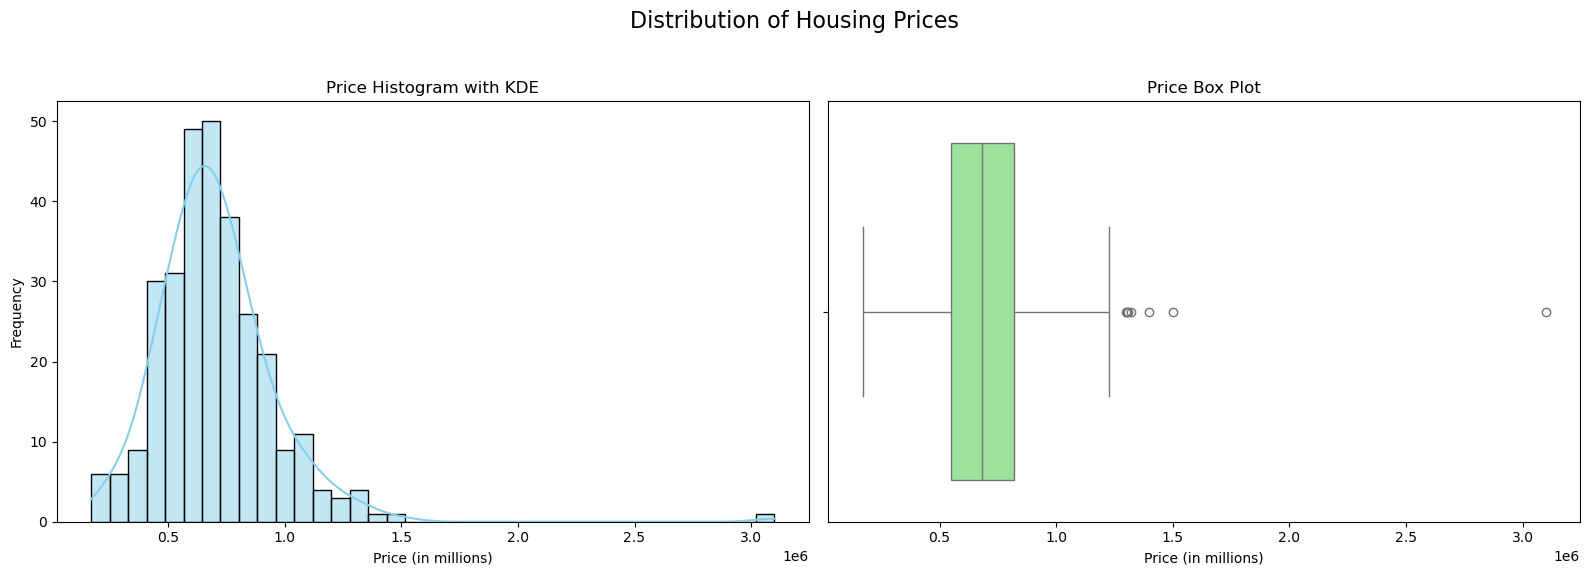

In [197]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Housing Prices', fontsize=16)

# Plot Histogram
sns.histplot(df_scaled['sold_price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Price Histogram with KDE')
axes[0].set_xlabel('Price (in millions)')
axes[0].set_ylabel('Frequency')

# Plot Box Plot
sns.boxplot(x=df_scaled['sold_price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Price Box Plot')
axes[1].set_xlabel('Price (in millions)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---

## Q2: Exploratory Data Analysis

### Price Distribution Analysis

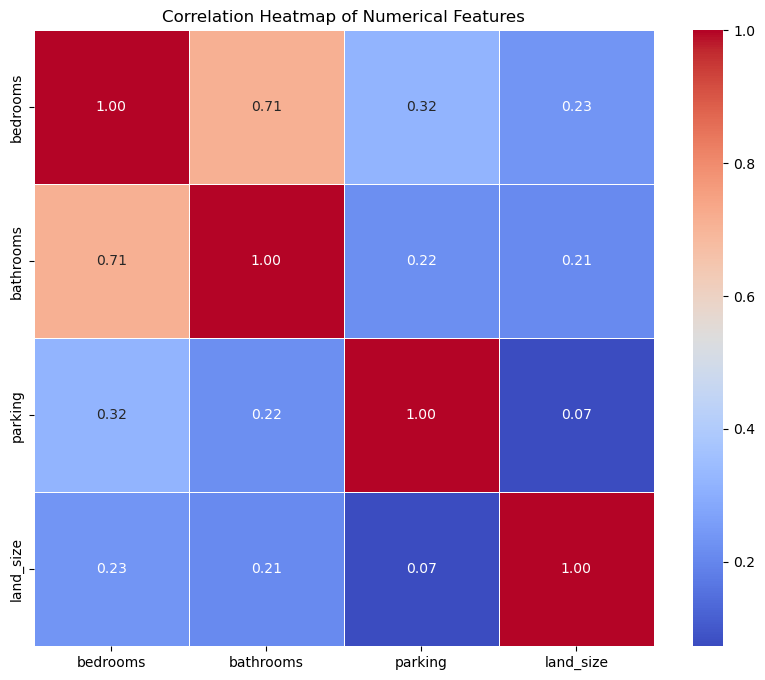

In [198]:
# Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Correlation Analysis

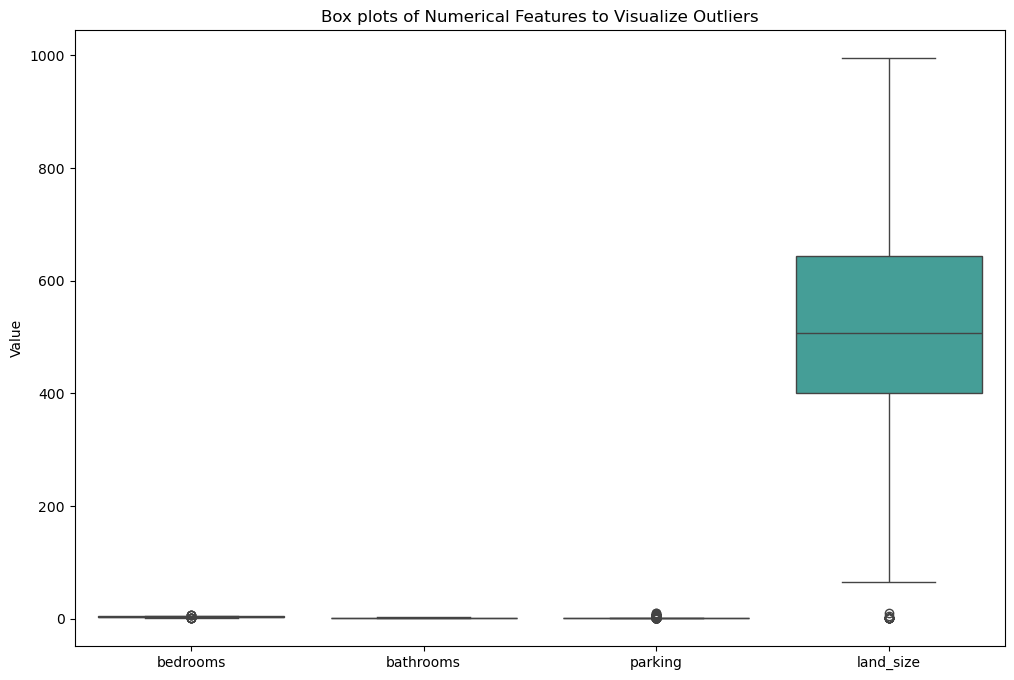

In [199]:
# Visualize outliers using box plots for numerical features
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numerical_features])
plt.title('Box plots of Numerical Features to Visualize Outliers')
plt.ylabel('Value')
plt.show()

### Outlier Analysis

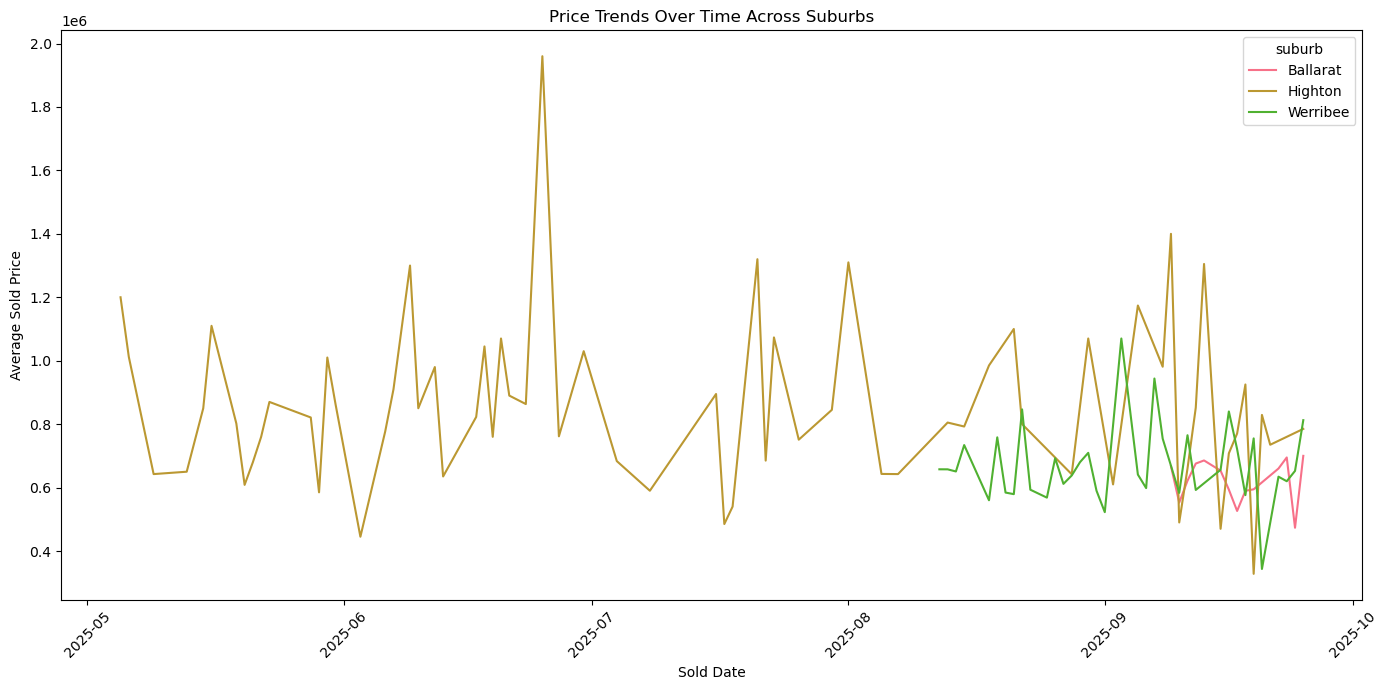

In [200]:
# Analyze price trends over time across suburbs
# Group by suburb and sold_date, then calculate the mean sold price
price_trends = df.groupby(['suburb', 'sold_date'])['sold_price'].mean().reset_index()

# Plot the price trends for each suburb
plt.figure(figsize=(14, 7))
sns.lineplot(data=price_trends, x='sold_date', y='sold_price', hue='suburb')
plt.title('Price Trends Over Time Across Suburbs')
plt.xlabel('Sold Date')
plt.ylabel('Average Sold Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Temporal Price Trends

---

# Q3: Model Development and Evaluation

## Data Preparation for Modeling

In [201]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select features for modeling (exclude target, date, and non-numeric columns)
feature_columns = [col for col in df_processed.columns 
                  if col not in ['sold_price', 'sold_date', 'address', 'listing_url']]

# Handle missing values in land_size for modeling
X = df_processed[feature_columns].copy()
X['land_size'] = X['land_size'].fillna(X['land_size'].median())

y = df_processed['sold_price']

print(f"Features used for modeling: {len(feature_columns)}")
print(f"Feature columns: {feature_columns}")
print(f"Dataset shape - X: {X.shape}, y: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Features used for modeling: 12
Feature columns: ['bedrooms', 'bathrooms', 'parking', 'land_size', 'suburb_Ballarat', 'suburb_Highton', 'suburb_Werribee', 'property_type_Apartment', 'property_type_House', 'property_type_Other', 'property_type_Unit', 'land_per_bedroom']
Dataset shape - X: (300, 12), y: (300,)
Training set: (240, 12), Test set: (60, 12)


## Three Regression Models

### Model 1: Linear Regression

In [202]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

print("Linear Regression Model trained successfully!")

Linear Regression Model trained successfully!


### Model 2: Random Forest Regression

In [203]:
# Model 2: Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


### Model 3: Gradient Boosting Regression

In [204]:
# Model 3: Gradient Boosting Regression
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

print("Gradient Boosting Model trained successfully!")

Gradient Boosting Model trained successfully!


## Model Evaluation Metrics

In [205]:
# Calculate evaluation metrics for all models
def calculate_metrics(y_true, y_pred, model_name, data_type):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Data': data_type,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }

# Collect all metrics
all_metrics = []

# Linear Regression metrics
all_metrics.append(calculate_metrics(y_train, lr_train_pred, 'Linear Regression', 'Train'))
all_metrics.append(calculate_metrics(y_test, lr_test_pred, 'Linear Regression', 'Test'))

# Random Forest metrics
all_metrics.append(calculate_metrics(y_train, rf_train_pred, 'Random Forest', 'Train'))
all_metrics.append(calculate_metrics(y_test, rf_test_pred, 'Random Forest', 'Test'))

# Gradient Boosting metrics
all_metrics.append(calculate_metrics(y_train, gb_train_pred, 'Gradient Boosting', 'Train'))
all_metrics.append(calculate_metrics(y_test, gb_test_pred, 'Gradient Boosting', 'Test'))

# Create DataFrame for better visualization
metrics_df = pd.DataFrame(all_metrics)
print("Model Performance Comparison:")
print("="*60)
print(metrics_df.to_string(index=False))
print("\n")

Model Performance Comparison:
            Model  Data           MAE          RMSE       R²
Linear Regression Train 106935.966807 176114.607844 0.569370
Linear Regression  Test  93856.391409 129883.223103 0.701143
    Random Forest Train  43820.643601  68411.840697 0.935021
    Random Forest  Test 111059.362001 178204.240304 0.437409
Gradient Boosting Train  53049.674017  67588.291668 0.936576
Gradient Boosting  Test 108372.515330 164433.824238 0.520996




## K-Fold Cross Validation

In [206]:
# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

cv_results = {}
for name, model in models.items():
    # Cross-validation scores for different metrics
    cv_mae = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error'))
    cv_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    cv_results[name] = {
        'MAE_mean': cv_mae.mean(),
        'MAE_std': cv_mae.std(),
        'RMSE_mean': cv_rmse.mean(),
        'RMSE_std': cv_rmse.std(),
        'R²_mean': cv_r2.mean(),
        'R²_std': cv_r2.std()
    }

# Display cross-validation results
print("5-Fold Cross Validation Results:")
print("="*50)
for model_name, results in cv_results.items():
    print(f"\n{model_name}:")
    print(f"  MAE: {results['MAE_mean']:.2f} (+/- {results['MAE_std']*2:.2f})")
    print(f"  RMSE: {results['RMSE_mean']:.2f} (+/- {results['RMSE_std']*2:.2f})")
    print(f"  R²: {results['R²_mean']:.3f} (+/- {results['R²_std']*2:.3f})")

5-Fold Cross Validation Results:

Linear Regression:
  MAE: 111722.82 (+/- 37234.26)
  RMSE: 167768.76 (+/- 121646.02)
  R²: 0.549 (+/- 0.272)

Random Forest:
  MAE: 110911.22 (+/- 34129.87)
  RMSE: 177869.27 (+/- 116202.32)
  R²: 0.501 (+/- 0.160)

Gradient Boosting:
  MAE: 112218.47 (+/- 29317.12)
  RMSE: 173328.57 (+/- 117152.84)
  R²: 0.529 (+/- 0.129)


---

## Q4: Feature Importance Analysis

In [207]:
# Feature Importance Analysis

# 1. Linear Regression Coefficients
lr_coef = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("Linear Regression Feature Importance (Absolute Coefficients):")
print("="*60)
print(lr_coef.head(10).to_string(index=False))
print("\n")

# 2. Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance:")
print("="*40)
print(rf_importance.head(10).to_string(index=False))
print("\n")

# 3. Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Gradient Boosting Feature Importance:")
print("="*40)
print(gb_importance.head(10).to_string(index=False))

Linear Regression Feature Importance (Absolute Coefficients):
                Feature    Coefficient  Abs_Coefficient
         suburb_Highton  150537.801577    150537.801577
              bathrooms  134129.941043    134129.941043
property_type_Apartment -104806.567724    104806.567724
        suburb_Ballarat  -94590.753329     94590.753329
    property_type_House   79808.380559     79808.380559
        suburb_Werribee  -55947.048249     55947.048249
    property_type_Other   40352.193432     40352.193432
                parking   33594.668044     33594.668044
               bedrooms   26209.265208     26209.265208
     property_type_Unit  -15354.006267     15354.006267


Random Forest Feature Importance:
            Feature  Importance
          land_size    0.308582
          bathrooms    0.298817
     suburb_Highton    0.122776
   land_per_bedroom    0.115565
           bedrooms    0.070593
            parking    0.056512
    suburb_Ballarat    0.012037
property_type_House    0.00592

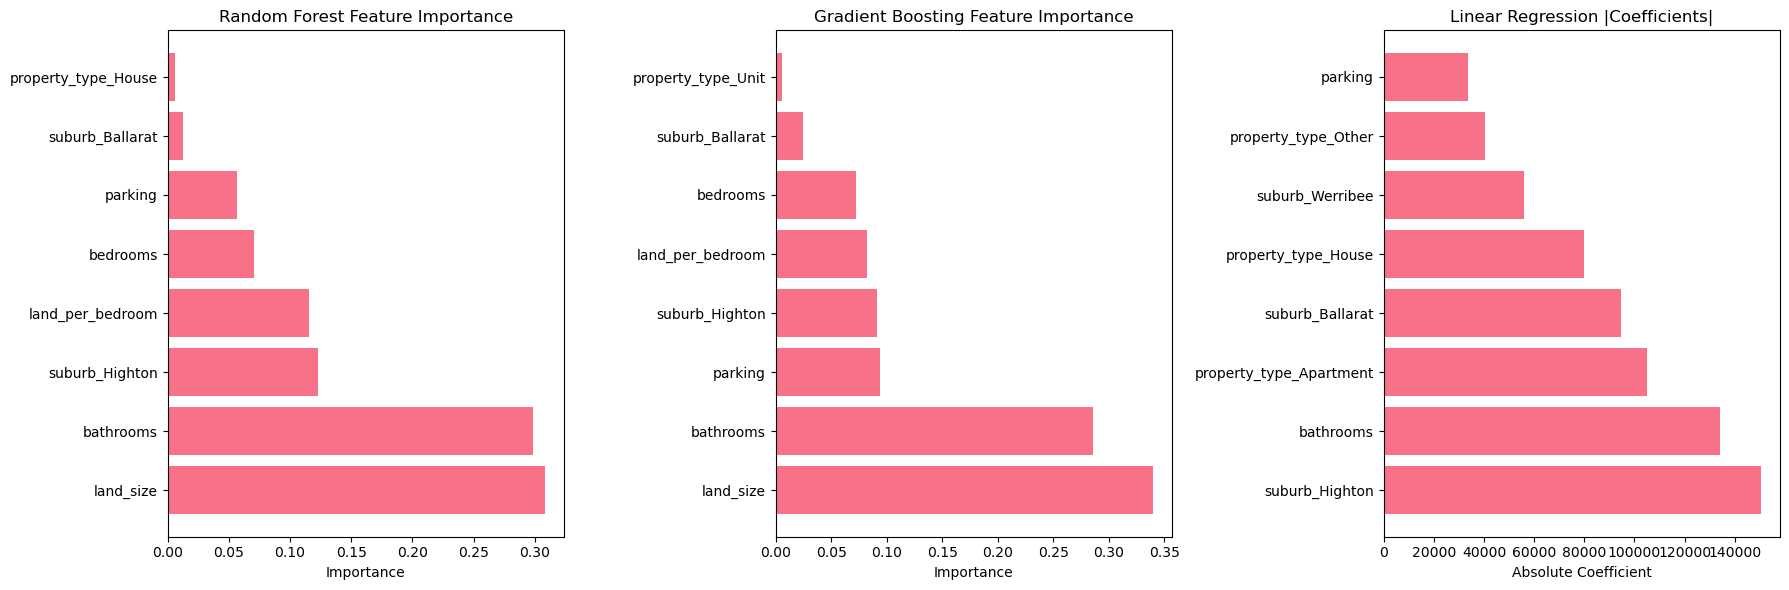

In [208]:
# Visualize Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest Feature Importance Plot
top_rf = rf_importance.head(8)
axes[0].barh(top_rf['Feature'], top_rf['Importance'])
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

# Gradient Boosting Feature Importance Plot
top_gb = gb_importance.head(8)
axes[1].barh(top_gb['Feature'], top_gb['Importance'])
axes[1].set_title('Gradient Boosting Feature Importance')
axes[1].set_xlabel('Importance')

# Linear Regression Coefficients Plot
top_lr = lr_coef.head(8)
axes[2].barh(top_lr['Feature'], top_lr['Abs_Coefficient'])
axes[2].set_title('Linear Regression |Coefficients|')
axes[2].set_xlabel('Absolute Coefficient')

plt.tight_layout()
plt.show()

---

## Q5: Model Deployment - Web Demo Application

In [ ]:
# Create Web Demo Application using Gradio
import gradio as gr
import joblib

# Save the best performing model (Linear Regression had best test R²)
joblib.dump(lr_model, 'housing_price_model_lr.pkl')

def predict_house_price(suburb, property_type, bedrooms, bathrooms, parking, land_size):
    # Create input array matching training features

    land_per_bedroom = land_size / bedrooms

    input_data = pd.DataFrame({
        'bedrooms': [bedrooms],
        'bathrooms': [bathrooms], 
        'parking': [parking],
        'land_size': [land_size if land_size > 0 else X['land_size'].median()],
        'suburb_Ballarat': [1 if suburb == 'Ballarat' else 0],
        'suburb_Highton': [1 if suburb == 'Highton' else 0],
        'suburb_Werribee': [1 if suburb == 'Werribee' else 0],
        'property_type_Apartment': [1 if property_type == 'Apartment' else 0],
        'property_type_House': [1 if property_type == 'House' else 0],
        'property_type_Other': [1 if property_type == 'Other' else 0],
        'property_type_Unit': [1 if property_type == 'Unit' else 0],
        'land_per_bedroom': [land_per_bedroom]
    })

    
    
    # Make prediction
    prediction = lr_model.predict(input_data)[0]
    
    return f"${prediction:,.0f}"

# Create Gradio interface
iface = gr.Interface(
    fn=predict_house_price,
    inputs=[
        gr.Dropdown(choices=["Ballarat", "Highton", "Werribee"], label="Suburb"),
        gr.Dropdown(choices=["House", "Apartment", "Unit", "Other"], label="Property Type"),
        gr.Slider(minimum=1, maximum=6, step=1, label="Bedrooms"),
        gr.Slider(minimum=1, maximum=4, step=1, label="Bathrooms"),
        gr.Slider(minimum=0, maximum=6, step=1, label="Parking Spaces"),
        gr.Number(label="Land Size (sqm)", value=0, info="Enter 0 if unknown")
    ],
    outputs=gr.Textbox(label="Predicted House Price"),
    title="Melbourne Housing Price Predictor",
    description="Enter property details to get an estimated price prediction",
    examples=[
        ["Highton", "House", 3, 2, 2, 650],
        ["Ballarat", "Apartment", 2, 1, 1, 0],
        ["Werribee", "Unit", 2, 2, 1, 300]
    ]
)


Web demo application ready! Run the cell below to launch.


In [ ]:
# Launch the web demo
iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://23e83b6c8061f5e7d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


To launch the web demo, uncomment the line above and run this cell.
The demo will be available at a local URL and a shareable public URL.


In [ ]:
#!/usr/bin/env python3
"""
Melbourne Housing Data Scraper
Scrapes housing data from realestate.com.au for three suburbs:
- Highton, VIC 3216
- Ballarat Greater Region, VIC
- Werribee, VIC 3030
"""

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import json
import logging

# Setup logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


class HousingScraper:
    def __init__(self):
        self.driver = None
        self.data = []

        # Suburb URLs
        self.suburb_urls = {
            "Highton": "https://www.realestate.com.au/sold/property-house-unit+apartment-in-highton,+vic+3216/list-",
            "Ballarat": "https://www.realestate.com.au/sold/property-house-unit+apartment-in-ballarat+-+greater+region,+vic/list-",
            "Werribee": "https://www.realestate.com.au/sold/property-house-unit+apartment-in-werribee,+vic+3030/list-",
        }

    def setup_chrome_driver(self):
        chrome_options = Options()
        # chrome_options.add_argument("--headless")  # Comment out to see browser
        # chrome_options.add_argument("--no-sandbox")
        # chrome_options.add_argument("--disable-dev-shm-usage")
        # chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--window-size=1920,1080")
        chrome_options.add_argument("--disable-blink-features=AutomationControlled")
        chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
        chrome_options.add_experimental_option("useAutomationExtension", False)

        print("Setting up Chrome WebDriver...")
        self.driver = webdriver.Chrome(options=chrome_options)
        self.driver.execute_script(
            "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
        )
        self.driver.set_page_load_timeout(30)
        print("✓ Chrome WebDriver initialized")

    def load_cookies_from_file(self, filename="www.realestate.com.au.cookies.json"):
        """Load cookies from JSON file"""
        try:
            with open(filename, "r") as f:
                cookies = json.load(f)
            print(f"✓ Loaded {len(cookies)} cookies from {filename}")
            return cookies
        except FileNotFoundError:
            print(f"✗ Cookie file {filename} not found!")
            return []
        except json.JSONDecodeError:
            print(f"✗ Error parsing {filename}!")
            return []

    def apply_cookies(self):
        """Apply cookies to the browser session"""
        # First navigate to the domain
        print("🌐 Navigating to realestate.com.au...")
        self.driver.get("https://www.realestate.com.au")
        time.sleep(5)

        # Debug: Check if page loaded
        print(f"📊 Page title: {self.driver.title}")
        print(f"📊 Current URL: {self.driver.current_url}")
        print(f"📊 Page source length: {len(self.driver.page_source)}")

        cookies = self.load_cookies_from_file()
        cookies_applied = 0
        for cookie in cookies:
            try:
                self.driver.add_cookie(cookie)
                cookies_applied += 1
            except Exception as e:
                logger.warning(
                    f"Could not add cookie {cookie.get('name', 'unknown')}: {e}"
                )

        print(f"✓ Applied {cookies_applied}/{len(cookies)} cookies to browser session")

        # Reload page with cookies
        print("🔄 Reloading page with cookies...")
        self.driver.get("https://www.realestate.com.au")
        time.sleep(5)

        # Debug after reload
        print(f"📊 After cookies - Page title: {self.driver.title}")
        print(f"📊 After cookies - Current URL: {self.driver.current_url}")

        # Check if we're blocked or redirected
        if (
            "blocked" in self.driver.page_source.lower()
            or "captcha" in self.driver.page_source.lower()
        ):
            print("⚠️  WARNING: Page may be blocked or showing CAPTCHA")

        if not self.driver.title or "realestate" not in self.driver.title.lower():
            print("⚠️  WARNING: Page title suggests site may not have loaded properly")

    def extract_price(self, price_text):
        """Extract numeric price from price text"""
        if not price_text:
            return None

        # Remove common price prefixes and clean
        price_text = price_text.replace("$", "").replace(",", "").strip()

        # Handle ranges (take the higher value)
        if "-" in price_text:
            prices = re.findall(r"\d+", price_text)
            if prices:
                return int(prices[-1])

        # Extract first number found
        numbers = re.findall(r"\d+", price_text)
        if numbers:
            return int(numbers[0])

        return None

    def extract_features(self, property_element):
        """Extract features from a property listing element"""
        try:
            # Initialize property data
            property_data = {
                "suburb": "",
                "address": "",
                "property_type": "",
                "bedrooms": None,
                "bathrooms": None,
                "parking": None,
                "land_size": None,
                "sold_price": None,
                "sold_date": "",
                "listing_url": "",
            }

            # Extract address # has class residential-card__details-link
            address_elem = property_element.select_one(
                "a.residential-card__details-link"
            )

            if address_elem:
                property_data["listing_url"] = (
                    "https://www.realestate.com.au" + address_elem.get("href", "")
                )

            address_elem = property_element.select_one(
                "a.residential-card__details-link span"
            )

            if address_elem:
                property_data["address"] = address_elem.text.strip()

            if property_data["address"]:
                address_parts = property_data["address"].split(",")
                # 401 Drummond Street South, Ballarat Central
                # after split we get ['401 Drummond Street South', 'Ballarat Central']
                # we want to get the last part
                if len(address_parts) > 1:
                    property_data["suburb"] = address_parts[-1].strip()
                else:
                    property_data["suburb"] = address_parts[0].strip()

            # Extract property type
            # first select ".residential-card__primary p"
            type_elem = property_element.select_one(".residential-card__primary > p")
            if type_elem:
                property_data["property_type"] = type_elem.text.strip()

            # Extract bedrooms, bathrooms, parking, land size
            features_ul = property_element.find(
                "ul", class_="residential-card__primary"
            )
            if features_ul:
                # Find all list items with aria-label
                feature_items = features_ul.find_all("li", {"aria-label": True})

                for item in feature_items:
                    aria_label = item.get("aria-label", "").lower()

                    # Extract the number from the p tag
                    p_tag = item.find("p")
                    if p_tag:
                        text = p_tag.text.strip()

                        if "bedroom" in aria_label:
                            beds = re.findall(r"\d+", text)
                            if beds:
                                property_data["bedrooms"] = int(beds[0])
                        elif "bathroom" in aria_label:
                            baths = re.findall(r"\d+", text)
                            if baths:
                                property_data["bathrooms"] = int(baths[0])
                        elif "car" in aria_label or "parking" in aria_label:
                            cars = re.findall(r"\d+", text)
                            if cars:
                                property_data["parking"] = int(cars[0])
                        elif "land size" in aria_label or "m²" in text:
                            # Extract numeric value from land size (e.g., "186m²" -> 186)
                            land_numbers = re.findall(r"\d+", text)
                            if land_numbers:
                                property_data["land_size"] = int(land_numbers[0])
                            else:
                                property_data["land_size"] = None

            # Extract sold price
            price_elem = property_element.find("span", class_="property-price")
            if price_elem:
                property_data["sold_price"] = self.extract_price(price_elem.text)

            # Extract sold date ".residential-card__content > span" text
            date_elem = property_element.select_one(".residential-card__content > span")
            if date_elem:
                property_data["sold_date"] = date_elem.text.strip()

            return property_data

        except Exception as e:
            logger.error(f"Error extracting features: {e}")
            return None

    def scrape_page(self, url, suburb_name):
        """Scrape a single page of listings"""
        try:
            logger.info(f"Scraping: {url}")
            self.driver.get(url)

            # Wait for page to load
            time.sleep(3)

            # Wait for listings to be present
            try:
                WebDriverWait(self.driver, 10).until(
                    EC.presence_of_element_located(
                        (By.CSS_SELECTOR, 'article[data-testid="ResidentialCard"]')
                    )
                )
            except:
                logger.warning(f"No listings found on page: {url}")
                return []

            # Get page source and parse with BeautifulSoup
            soup = BeautifulSoup(self.driver.page_source, "html.parser")

            # Find property listings
            listings = soup.find_all("article", {"data-testid": "ResidentialCard"})

            page_data = []
            for listing in listings:
                property_data = self.extract_features(listing)
                if property_data:
                    property_data["suburb"] = suburb_name
                    page_data.append(property_data)

            logger.info(f"Found {len(page_data)} properties on this page")
            return page_data

        except Exception as e:
            logger.error(f"Error scraping page {url}: {e}")
            return []

    def scrape_suburb(self, suburb_name, target_count=50):
        """Scrape properties for a specific suburb"""
        logger.info(f"Starting to scrape {suburb_name}")
        logger.info(f"Starting to scrape {self.suburb_urls[suburb_name]}")
        base_url = self.suburb_urls[suburb_name]

        page = 1
        suburb_data = []

        while len(suburb_data) < target_count and page <= 4:  # Limit to 4 pages
            url = f"{base_url}{page}"
            print(f"Scraping {url}")
            page_data = self.scrape_page(url, suburb_name)

            if not page_data:
                logger.info(f"No more data found for {suburb_name} at page {page}")
                break

            suburb_data.extend(page_data)
            logger.info(
                f"{suburb_name}: {len(suburb_data)} properties collected so far"
            )

            page += 1
            time.sleep(5)  # Be respectful with requests

        logger.info(f"Completed scraping {suburb_name}: {len(suburb_data)} properties")
        return suburb_data[:target_count]  # Return up to target_count

    def scrape_all_suburbs(self):
        """Scrape all three suburbs"""
        logger.info("Starting data collection for all suburbs")

        # Setup browser and cookies
        self.setup_chrome_driver()
        self.apply_cookies()

        try:
            for suburb_name in self.suburb_urls.keys():
                suburb_data = self.scrape_suburb(suburb_name, target_count=150)
                self.data.extend(suburb_data)
                logger.info(f"Total properties collected: {len(self.data)}")
                time.sleep(4)  # Pause between suburbs

            logger.info(
                f"Data collection completed. Total properties: {len(self.data)}"
            )

        finally:
            # Always close the browser
            if self.driver:
                self.driver.quit()
                print("✓ Browser closed")

    def save_to_csv(self, filename="melbourne_housing_data.csv"):
        """Save collected data to CSV file"""
        if not self.data:
            logger.warning("No data to save")
            return

        df = pd.DataFrame(self.data)

        # Clean and organize columns
        columns_order = [
            "suburb",
            "address",
            "property_type",
            "bedrooms",
            "bathrooms",
            "parking",
            "land_size",
            "sold_price",
            "sold_date",
            "listing_url",
        ]

        df = df.reindex(columns=columns_order)
        df.to_csv(filename, index=False)

        logger.info(f"Data saved to {filename}")
        logger.info(f"Dataset shape: {df.shape}")

        # Print summary statistics
        print("\n=== DATA COLLECTION SUMMARY ===")
        print(f"Total properties collected: {len(df)}")
        print(f"Properties per suburb:")
        print(df["suburb"].value_counts())
        print(f"\nProperty types:")
        print(df["property_type"].value_counts())
        print(f"\nPrice statistics:")
        print(df["sold_price"].describe())


def test_basic_setup():
    """Test if Chrome and basic navigation works"""
    print("🧪 Testing basic browser setup...")
    scraper = HousingScraper()

    try:
        scraper.setup_chrome_driver()

        # Test navigation to a simple site first
        print("🌐 Testing navigation to Google...")
        scraper.driver.get("https://www.google.com")
        time.sleep(3)
        print(f"✓ Google title: {scraper.driver.title}")

        # Now test realestate.com.au
        scraper.apply_cookies()

        # Test one listing page
        test_url = "https://www.realestate.com.au/sold/in-highton,+vic+3216/list-1"
        print(f"🧪 Testing listing page: {test_url}")
        scraper.driver.get(test_url)
        time.sleep(5)

        print(f"📊 Listing page title: {scraper.driver.title}")
        print(f"📊 Page source length: {len(scraper.driver.page_source)}")

        # Check for key elements
        soup = BeautifulSoup(scraper.driver.page_source, "html.parser")
        listings = soup.find_all("article", {"data-testid": "ResidentialCard"})
        print(f"📊 Found {len(listings)} property listings")

        if len(listings) == 0:
            print("⚠️  No listings found - checking page content...")
            # Save page source for debugging
            with open("debug_page_source.html", "w") as f:
                f.write(scraper.driver.page_source)
            print("💾 Saved page source to debug_page_source.html")

        input("Press Enter to continue or Ctrl+C to exit...")

    except Exception as e:
        print(f"❌ Error during test: {e}")
    finally:
        if scraper.driver:
            scraper.driver.quit()


def main():
    """Main function to run the scraper"""
    import sys

    # Check if we want to run test mode
    if len(sys.argv) > 1 and sys.argv[1] == "test":
        test_basic_setup()
        return

    scraper = HousingScraper()

    try:
        scraper.scrape_all_suburbs()
        scraper.save_to_csv()

    except KeyboardInterrupt:
        logger.info("Scraping interrupted by user")
        if scraper.data:
            scraper.save_to_csv("partial_melbourne_housing_data.csv")
    except Exception as e:
        logger.error(f"Unexpected error: {e}")
        if scraper.data:
            scraper.save_to_csv("error_melbourne_housing_data.csv")
    finally:
        # Ensure browser is closed
        if scraper.driver:
            scraper.driver.quit()


if __name__ == "__main__":
    main()
